In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings 

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['axes.labelweight'] = 'bold'
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['figure.titlesize'] = 14
plt.rcParams['font.size'] = 14

warnings.filterwarnings("ignore")

algos = ['qlearning', 'dqn', 'sac_continuous_action']
algos_name = ['Q-Learning', 'DQN', 'SAC']
#cities_label = {"London":"london", 
#                "New York":"newyork", 
#                "Beijing":"beijing",
#                "Hong Kong":"hongkong",
#                "Singapore":"singapore"}
w_labels = {'0.3': 'london-0.3', '0.5': 'london-0.5', '0.7': 'london-0.7'}


In [2]:
df = pd.read_csv('rl_training_log/training.csv')
df.head()

,global_step,clmux-w-var/clmux-london-0.7__sac_continuous_action__42 - charts/episodic_return,clmux-w-var/clmux-london-0.7__sac_continuous_action__42 - charts/episodic_return__MIN,clmux-w-var/clmux-london-0.7__sac_continuous_action__42 - charts/episodic_return__MAX,clmux-w-var/clmux-london-0.7__sac_continuous_action__42 - _step,clmux-w-var/clmux-london-0.7__sac_continuous_action__42 - _step__MIN,clmux-w-var/clmux-london-0.7__sac_continuous_action__42 - _step__MAX,clmux-w-var/clmux-london-0.3__dqn__42 - charts/episodic_return,clmux-w-var/clmux-london-0.3__dqn__42 - charts/episodic_return__MIN,clmux-w-var/clmux-london-0.3__dqn__42 - charts/episodic_return__MAX,...,clmux-w-var/clmux-london-0.7__qlearning__42 - charts/episodic_return__MAX,clmux-w-var/clmux-london-0.7__qlearning__42 - _step,clmux-w-var/clmux-london-0.7__qlearning__42 - _step__MIN,clmux-w-var/clmux-london-0.7__qlearning__42 - _step__MAX,clmux-w-var/clmux-london-0.5__qlearning__42 - charts/episodic_return,clmux-w-var/clmux-london-0.5__qlearning__42 - charts/episodic_return__MIN,clmux-w-var/clmux-london-0.5__qlearning__42 - charts/episodic_return__MAX,clmux-w-var/clmux-london-0.5__qlearning__42 - _step,clmux-w-var/clmux-london-0.5__qlearning__42 - _step__MIN,clmux-w-var/clmux-london-0.5__qlearning__42 - _step__MAX
0,8686,-1731.4604,-1731.4604,-1731.4604,0.0,0.0,0.0,-3260.9055,-3260.9055,-3260.9055,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,8687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1757.5051,0.0,0.0,0.0,-2548.7043,-2548.7043,-2548.7043,0.0,0.0,0.0
2,17373,-1528.2659,-1528.2659,-1528.2659,1046.0,1046.0,1046.0,-2928.9170,-2928.9170,-2928.9170,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,17374,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1744.9290,2.0,2.0,2.0,-2527.1270,-2527.1270,-2527.1270,2.0,2.0,2.0
4,26060,-1384.4908,-1384.4908,-1384.4908,2092.0,2092.0,2092.0,-2686.0251,-2686.0251,-2686.0251,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
cols = [x for x in df.columns if 'return' in x]
cols = [x for x in cols if 'MIN' not in x]
cols = [x for x in cols if 'MAX' not in x]
cols.append('global_step')

In [4]:
df = df[cols]
df.head()

,clmux-w-var/clmux-london-0.7__sac_continuous_action__42 - charts/episodic_return,clmux-w-var/clmux-london-0.3__dqn__42 - charts/episodic_return,clmux-w-var/clmux-london-0.7__dqn__42 - charts/episodic_return,clmux-w-var/clmux-london-0.3__sac_continuous_action__42 - charts/episodic_return,clmux-w-var/clmux-london-0.5__dqn__42 - charts/episodic_return,clmux-w-var/clmux-london-0.5__sac_continuous_action__42 - charts/episodic_return,clmux-w-var/clmux-london-0.3__qlearning__42 - charts/episodic_return,clmux-w-var/clmux-london-0.7__qlearning__42 - charts/episodic_return,clmux-w-var/clmux-london-0.5__qlearning__42 - charts/episodic_return,global_step
0,-1731.4604,-3260.9055,-1729.6107,-3283.5535,-2495.2490,-2507.5010,NaN,NaN,NaN,8686
1,NaN,NaN,NaN,NaN,NaN,NaN,-3339.9036,-1757.5051,-2548.7043,8687
2,-1528.2659,-2928.9170,-1613.9788,-3138.4640,-2272.6934,-2309.7617,NaN,NaN,NaN,17373
3,NaN,NaN,NaN,NaN,NaN,NaN,-3309.3250,-1744.9290,-2527.1270,17374
4,-1384.4908,-2686.0251,-1515.1632,-3124.2534,-2100.6438,-2110.0542,NaN,NaN,NaN,26060


In [5]:
rename_cols = {}
for col in cols:
    if 'return' in col:
        rename_cols[col] = col.split('__42')[0].split('/clmux')[1]
    else:
        rename_cols[col] = col
df = df.rename(columns=rename_cols)
df

,-london-0.7__sac_continuous_action,-london-0.3__dqn,-london-0.7__dqn,-london-0.3__sac_continuous_action,-london-0.5__dqn,-london-0.5__sac_continuous_action,-london-0.3__qlearning,-london-0.7__qlearning,-london-0.5__qlearning,global_step
0,-1731.4604,-3260.90550,-1729.61070,-3283.5535,-2495.24900,-2507.5010,NaN,NaN,NaN,8686
1,NaN,NaN,NaN,NaN,NaN,NaN,-3339.9036,-1757.5051,-2548.7043,8687
2,-1528.2659,-2928.91700,-1613.97880,-3138.4640,-2272.69340,-2309.7617,NaN,NaN,NaN,17373
3,NaN,NaN,NaN,NaN,NaN,NaN,-3309.3250,-1744.9290,-2527.1270,17374
4,-1384.4908,-2686.02510,-1515.16320,-3124.2534,-2100.64380,-2110.0542,NaN,NaN,NaN,26060
5,NaN,NaN,NaN,NaN,NaN,NaN,-3410.5890,-1784.4409,-2597.5151,26061
6,-1310.9548,-2422.20680,-1432.24490,-3144.3643,-1922.39280,-1985.6031,NaN,NaN,NaN,34747
7,NaN,NaN,NaN,NaN,NaN,NaN,-3432.4583,-1793.5823,-2613.0203,34748
8,-1295.5443,-2175.32000,-1345.38930,-2995.9120,-1757.02880,-1886.0010,NaN,NaN,NaN,43434
9,NaN,NaN,NaN,NaN,NaN,NaN,-3408.7166,-1783.7828,-2596.2498,43435


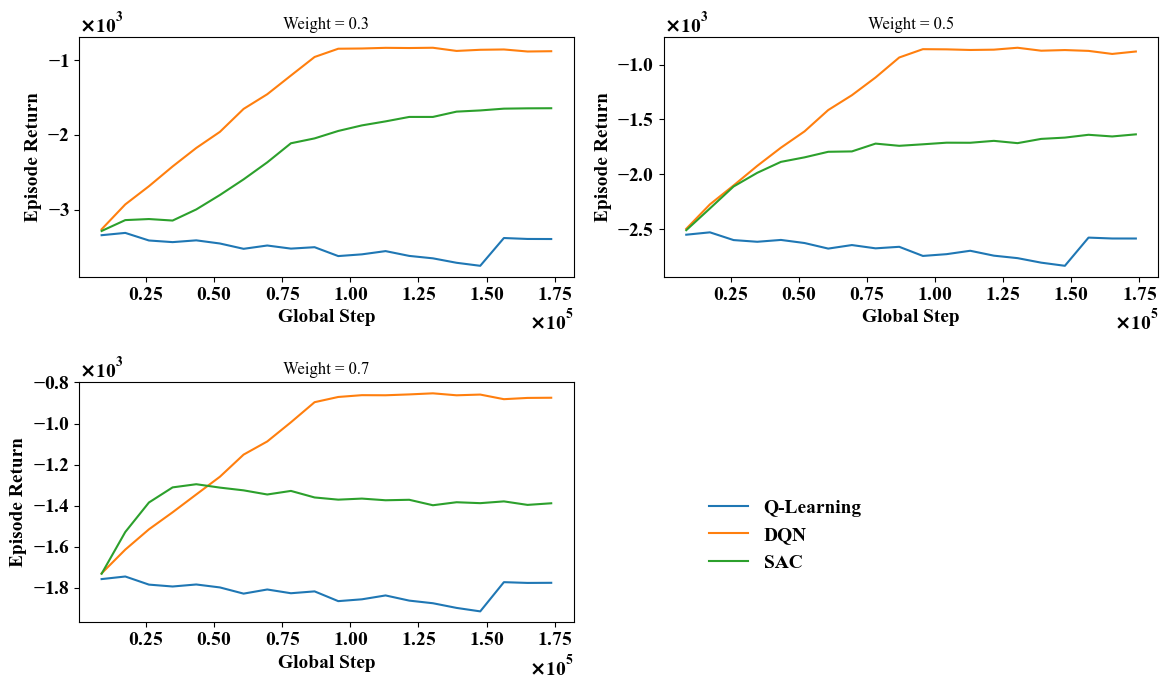

In [6]:
fig = plt.figure(figsize=(12, 10))

#for city in cities_label.values():
titles = ['Weight = 0.3', 'Weight = 0.5', 'Weight = 0.7']
for w in w_labels.values():
    ax = fig.add_subplot(3, 2, list(w_labels.values()).index(w)+1)
    for algo in algos:
        sns.lineplot(data=df, x='global_step', y='-' + w + '__' + algo, 
                     label=algos_name[algos.index(algo)], ax=ax, legend=False)
        ax.set_title(titles[list(w_labels.values()).index(w)], fontsize=12)
        ax.set_xlabel('Global Step')
        ax.set_ylabel('Episode Return')
        ax.yaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='y', scilimits=(0, 0))
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter(useMathText=True))
        ax.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))
        
handles, labels = ax.get_legend_handles_labels()[0:3]
fig.legend(handles, labels, loc='lower right', ncol=1, frameon=False, bbox_to_anchor=(0.75, 0.4))
        
plt.tight_layout()
plt.savefig('./figs/training.pdf', dpi = 300, bbox_inches='tight')

In [7]:
df = pd.read_csv('rl_eval_data/eval.csv')
cols = [x for x in df.columns if ('return' in x) or ('EvalRewards' in x)]
cols = [x for x in cols if 'MIN' not in x]
cols = [x for x in cols if 'MAX' not in x]
cols.append('global_step')
df = df[cols]
df

,clmux-w-var/clmux-london-0.7__sac_continuous_action__42 - eval/scale_episodic_return,clmux-w-var/clmux-london-0.3__dqn__42 - eval/episodic_return,clmux-w-var/clmux-london-0.7__dqn__42 - eval/episodic_return,clmux-w-var/clmux-london-0.3__sac_continuous_action__42 - eval/scale_episodic_return,clmux-w-var/clmux-london-0.5__dqn__42 - eval/episodic_return,clmux-w-var/clmux-london-0.5__sac_continuous_action__42 - eval/scale_episodic_return,clmux-w-var/clmux-london-0.3__qlearning__42 - EvalRewards,clmux-w-var/clmux-london-0.7__qlearning__42 - EvalRewards,clmux-w-var/clmux-london-0.5__qlearning__42 - EvalRewards,global_step
0,-1403.2152,-1050.27280,-845.4508,-1652.9652,-857.20920,-1651.5288,-4044.1602,-2031.8364,-3037.9983,0
1,-1385.1605,-726.60840,-823.4877,-1630.6180,-811.84300,-1628.3113,-4033.4420,-2026.4552,-3029.9485,1
2,-1389.1504,-717.49554,-825.8925,-1627.6332,-811.83325,-1628.2110,-4067.3560,-2042.2897,-3054.8228,2


In [8]:
rename_cols = {}
cols_w = []
for col in cols:
    
    if 'return' in col or 'EvalRewards' in col:
        rename_cols[col] = col.split('__42__')[0].split('/clmux-')[1]
    else:
        rename_cols[col] = col
    
    if ('0.3' in col) or ('0.5' in col) or ('0.7' in col) or ('global_step' in col):
    
        cols_w.append(col)
    
print(rename_cols)
print(cols_w)
df = df[cols_w].rename(columns=rename_cols)
df

{'clmux-w-var/clmux-london-0.7__sac_continuous_action__42 - eval/scale_episodic_return': 'london-0.7__sac_continuous_action__42 - eval/scale_episodic_return', 'clmux-w-var/clmux-london-0.3__dqn__42 - eval/episodic_return': 'london-0.3__dqn__42 - eval/episodic_return', 'clmux-w-var/clmux-london-0.7__dqn__42 - eval/episodic_return': 'london-0.7__dqn__42 - eval/episodic_return', 'clmux-w-var/clmux-london-0.3__sac_continuous_action__42 - eval/scale_episodic_return': 'london-0.3__sac_continuous_action__42 - eval/scale_episodic_return', 'clmux-w-var/clmux-london-0.5__dqn__42 - eval/episodic_return': 'london-0.5__dqn__42 - eval/episodic_return', 'clmux-w-var/clmux-london-0.5__sac_continuous_action__42 - eval/scale_episodic_return': 'london-0.5__sac_continuous_action__42 - eval/scale_episodic_return', 'clmux-w-var/clmux-london-0.3__qlearning__42 - EvalRewards': 'london-0.3__qlearning__42 - EvalRewards', 'clmux-w-var/clmux-london-0.7__qlearning__42 - EvalRewards': 'london-0.7__qlearning__42 - E

,london-0.7__sac_continuous_action__42 - eval/scale_episodic_return,london-0.3__dqn__42 - eval/episodic_return,london-0.7__dqn__42 - eval/episodic_return,london-0.3__sac_continuous_action__42 - eval/scale_episodic_return,london-0.5__dqn__42 - eval/episodic_return,london-0.5__sac_continuous_action__42 - eval/scale_episodic_return,london-0.3__qlearning__42 - EvalRewards,london-0.7__qlearning__42 - EvalRewards,london-0.5__qlearning__42 - EvalRewards,global_step
0,-1403.2152,-1050.27280,-845.4508,-1652.9652,-857.20920,-1651.5288,-4044.1602,-2031.8364,-3037.9983,0
1,-1385.1605,-726.60840,-823.4877,-1630.6180,-811.84300,-1628.3113,-4033.4420,-2026.4552,-3029.9485,1
2,-1389.1504,-717.49554,-825.8925,-1627.6332,-811.83325,-1628.2110,-4067.3560,-2042.2897,-3054.8228,2


In [9]:
df_melted = df.melt(id_vars=['global_step'], var_name='city_algo', value_name='return')
df_melted['city'] = df_melted['city_algo'].apply(lambda x: x.split('__')[0])
df_melted['algo'] = df_melted['city_algo'].apply(lambda x: x.split('__')[1])

In [10]:
df_melted['return'] = df_melted['return'].astype(float)

In [11]:
#ities_label_r = {v: k for k, v in cities_label.items()}
w_label_r = {v: k for k, v in w_labels.items()}
df_melted = df_melted.replace({'city': w_label_r}).replace({'algo': {algos[i]: algos_name[i] for i in range(len(algos))}})
# 按照 cities_label 的顺序重新排序
w_labels_list = list(w_labels.values())
cities_label = {w_labels_list[i]: i for i in range(len(w_labels_list))}
df_melted['city_num'] = df_melted['city'].map(cities_label)
df_melted = df_melted.sort_values(by=['city', 'algo']).reset_index(drop=True)
df_melted

,global_step,city_algo,return,city,algo,city_num
0,0,london-0.3__dqn__42 - eval/episodic_return,-1050.27280,0.3,DQN,NaN
1,1,london-0.3__dqn__42 - eval/episodic_return,-726.60840,0.3,DQN,NaN
2,2,london-0.3__dqn__42 - eval/episodic_return,-717.49554,0.3,DQN,NaN
3,0,london-0.3__qlearning__42 - EvalRewards,-4044.16020,0.3,Q-Learning,NaN
4,1,london-0.3__qlearning__42 - EvalRewards,-4033.44200,0.3,Q-Learning,NaN
5,2,london-0.3__qlearning__42 - EvalRewards,-4067.35600,0.3,Q-Learning,NaN
6,0,london-0.3__sac_continuous_action__42 - eval/s...,-1652.96520,0.3,SAC,NaN
7,1,london-0.3__sac_continuous_action__42 - eval/s...,-1630.61800,0.3,SAC,NaN
8,2,london-0.3__sac_continuous_action__42 - eval/s...,-1627.63320,0.3,SAC,NaN
9,0,london-0.5__dqn__42 - eval/episodic_return,-857.20920,0.5,DQN,NaN


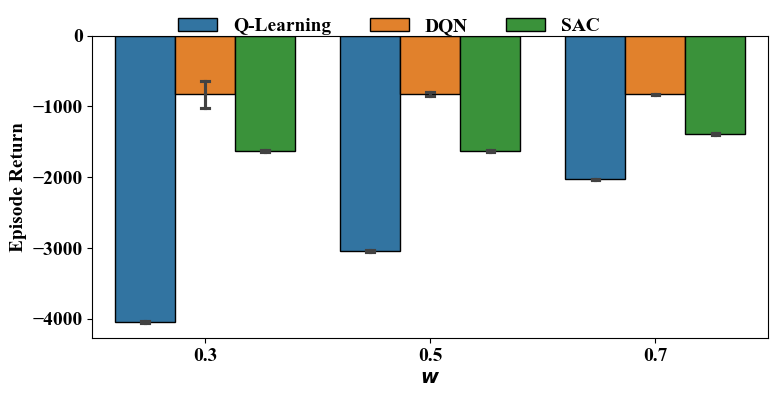

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
colors = [ "#0FB398", "#AF3EAE","#4193A5"]
sns.barplot(data=df_melted, x='city', y='return', hue='algo', hue_order=algos_name, ci='sd',
            #palette=colors, 
            linestyle='-', linewidth=1, edgecolor='black',
            capsize=0.1, ax=ax, legend=True)
ax.legend_.remove()
fig.legend(loc='upper center', ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))
plt.xlabel('$w$')
plt.ylabel('Episode Return')
plt.tight_layout()
plt.savefig('./figs/eval.pdf', dpi = 300, bbox_inches='tight')